---
## 1️⃣ Setup & Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    f1_score, 
    precision_score, 
    recall_score,
    accuracy_score
)
from sklearn.model_selection import GridSearchCV

# Handle class imbalance
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠ imbalanced-learn not installed. Install with: pip install imbalanced-learn")

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not installed. Install with: pip install xgboost")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)

print("✓ Imports successful!")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  SMOTE Available: {SMOTE_AVAILABLE}")
print(f"  XGBoost Available: {XGBOOST_AVAILABLE}")

✓ Imports successful!
  NumPy: 2.3.5
  Pandas: 2.3.3
  SMOTE Available: True
  XGBoost Available: True


---
## 2️⃣ Load TESS Mission Data

In [2]:
# Define paths
BASE_DIR = Path('f:/FYP')
DATA_DIR = BASE_DIR / 'data' / 'processed' / 'tess'
ARTIFACTS_DIR = BASE_DIR / 'artifacts' / 'tess'
MODELS_DIR = BASE_DIR / 'models'

# Create models directory
MODELS_DIR.mkdir(exist_ok=True)

print(f"📁 Data Directory: {DATA_DIR}")
print(f"📁 Models Directory: {MODELS_DIR}")
print(f"\n✓ Directories configured")

📁 Data Directory: f:\FYP\data\processed\tess
📁 Models Directory: f:\FYP\models

✓ Directories configured


In [3]:
print("Loading TESS Mission Data...\n")

# Load datasets (MinMax scaled for tree models)
train_df = pd.read_csv(DATA_DIR / 'tess_habitability_train_minmax.csv')
val_df = pd.read_csv(DATA_DIR / 'tess_habitability_val_minmax.csv')
test_df = pd.read_csv(DATA_DIR / 'tess_habitability_test_minmax.csv')

# Load metadata
with open(ARTIFACTS_DIR / 'tess_habitability_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

# Separate features and targets
feature_cols = [col for col in train_df.columns if col not in ['target', 'target_name']]

X_train = train_df[feature_cols]
y_train = train_df['target']
y_train_name = train_df['target_name']

X_val = val_df[feature_cols]
y_val = val_df['target']
y_val_name = val_df['target_name']

X_test = test_df[feature_cols]
y_test = test_df['target']
y_test_name = test_df['target_name']

# Print info
print(f"📊 Dataset Statistics:")
print(f"  Training samples:   {len(X_train):,}")
print(f"  Validation samples: {len(X_val):,}")
print(f"  Test samples:       {len(X_test):,}")
print(f"  Features:           {len(feature_cols)}")

print(f"\n🎯 Class Distribution (Training):")
class_dist = y_train_name.value_counts()
for class_name, count in class_dist.items():
    percentage = (count / len(y_train)) * 100
    print(f"  {class_name:30} {count:5,} ({percentage:5.2f}%)")

# Target encoding mapping
target_mapping = dict(zip(y_train, y_train_name))
print(f"\n🔢 Target Encoding:")
for code, name in sorted(target_mapping.items()):
    print(f"  {code} -> {name}")

print("\n✓ TESS data loaded successfully!")

Loading TESS Mission Data...

📊 Dataset Statistics:
  Training samples:   2,961
  Validation samples: 987
  Test samples:       987
  Features:           44

🎯 Class Distribution (Training):
  NON_HABITABLE                  2,866 (96.79%)
  HABITABILITY_ZONE                 89 ( 3.01%)
  POTENTIALLY_HABITABLE              6 ( 0.20%)

🔢 Target Encoding:
  0 -> HABITABILITY_ZONE
  1 -> NON_HABITABLE
  2 -> POTENTIALLY_HABITABLE

✓ TESS data loaded successfully!


---
## 3️⃣ Handle Class Imbalance with SMOTE

In [4]:
if not SMOTE_AVAILABLE:
    print("⚠ SMOTE not available. Training without oversampling.")
    print("   Install with: pip install imbalanced-learn")
    X_train_balanced = X_train
    y_train_balanced = y_train
else:
    print("Applying SMOTE to balance classes...\n")
    
    print(f"📊 Original Class Distribution:")
    original_dist = pd.Series(y_train).value_counts().sort_index()
    for idx, count in original_dist.items():
        percentage = (count / len(y_train)) * 100
        class_name = target_mapping[idx]
        print(f"  {class_name:30} {count:5,} ({percentage:5.2f}%)")
    
    # Use k_neighbors=1 for very small minority classes
    min_class_size = min(original_dist)
    k_neighbors = min(5, min_class_size - 1) if min_class_size > 1 else 1
    
    print(f"\n⚙️ SMOTE Configuration:")
    print(f"  k_neighbors: {k_neighbors}")
    print(f"  sampling_strategy: 'not majority' (balance minority classes)")
    
    try:
        smote = SMOTE(
            sampling_strategy='not majority',
            k_neighbors=k_neighbors,
            random_state=42
        )
        
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
        
        print(f"\n📊 After SMOTE Class Distribution:")
        new_dist = pd.Series(y_train_balanced).value_counts().sort_index()
        for idx, count in new_dist.items():
            percentage = (count / len(y_train_balanced)) * 100
            change = count - original_dist.get(idx, 0)
            class_name = target_mapping[idx]
            print(f"  {class_name:30} {count:5,} ({percentage:5.2f}%) [+{change:,}]")
        
        print(f"\n✓ Total samples: {len(X_train):,} -> {len(X_train_balanced):,}")
        
    except Exception as e:
        print(f"\n⚠ SMOTE failed: {str(e)}")
        print("   Using original data without oversampling.")
        X_train_balanced = X_train
        y_train_balanced = y_train

Applying SMOTE to balance classes...

📊 Original Class Distribution:
  HABITABILITY_ZONE                 89 ( 3.01%)
  NON_HABITABLE                  2,866 (96.79%)
  POTENTIALLY_HABITABLE              6 ( 0.20%)

⚙️ SMOTE Configuration:
  k_neighbors: 5
  sampling_strategy: 'not majority' (balance minority classes)

⚠ SMOTE failed: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
   Using original data without oversa

---
## 4️⃣ Train Random Forest Model

In [5]:
print("="*60)
print("Training Random Forest Classifier")
print("="*60)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Base model
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

n_combinations = (len(param_grid['n_estimators']) * 
                  len(param_grid['max_depth']) * 
                  len(param_grid['min_samples_split']) * 
                  len(param_grid['min_samples_leaf']) * 
                  len(param_grid['class_weight']))

print(f"\n🔍 Hyperparameter tuning with GridSearchCV...")
print(f"   Testing {n_combinations} parameter combinations")
print(f"   This may take 5-10 minutes...\n")

# Grid search
grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\n✓ Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Best model
tess_rf_model = grid_search.best_estimator_

# Validation performance
val_pred = tess_rf_model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred, average='weighted')

print(f"\n📊 Validation Performance:")
print(f"  Accuracy:     {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Weighted F1:  {val_f1:.4f}")

# Save model
rf_model_path = MODELS_DIR / 'tess_random_forest_model.pkl'
with open(rf_model_path, 'wb') as f:
    pickle.dump(tess_rf_model, f)
print(f"\n💾 Model saved: {rf_model_path}")

Training Random Forest Classifier

🔍 Hyperparameter tuning with GridSearchCV...
   Testing 48 parameter combinations
   This may take 5-10 minutes...

Fitting 3 folds for each of 48 candidates, totalling 144 fits

✓ Best parameters found:
  class_weight: balanced
  max_depth: 20
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 100

📊 Validation Performance:
  Accuracy:     0.9970 (99.70%)
  Weighted F1:  0.9970

💾 Model saved: f:\FYP\models\tess_random_forest_model.pkl


---
## 5️⃣ Train XGBoost Model

In [6]:
if not XGBOOST_AVAILABLE:
    print("⚠ XGBoost not available. Skipping XGBoost training.")
    print("   Install with: pip install xgboost")
    tess_xgb_model = None
else:
    print("="*60)
    print("Training XGBoost Classifier")
    print("="*60)
    
    # Calculate number of classes
    n_classes = len(np.unique(y_train_balanced))
    
    # XGBoost parameters
    params = {
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 200,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss'
    }
    
    print("\n⚙️ XGBoost Configuration:")
    for param, value in params.items():
        print(f"  {param}: {value}")
    
    print("\n🔄 Training XGBoost model...")
    
    try:
        tess_xgb_model = xgb.XGBClassifier(**params)
        
        tess_xgb_model.fit(
            X_train_balanced, y_train_balanced,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # Validation performance
        val_pred = tess_xgb_model.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average='weighted')
        
        print(f"\n📊 Validation Performance:")
        print(f"  Accuracy:     {val_acc:.4f} ({val_acc*100:.2f}%)")
        print(f"  Weighted F1:  {val_f1:.4f}")
        
        # Save model
        xgb_model_path = MODELS_DIR / 'tess_xgboost_model.pkl'
        with open(xgb_model_path, 'wb') as f:
            pickle.dump(tess_xgb_model, f)
        print(f"\n💾 Model saved: {xgb_model_path}")
        
    except Exception as e:
        print(f"\n⚠ XGBoost training failed: {str(e)}")
        tess_xgb_model = None

Training XGBoost Classifier

⚙️ XGBoost Configuration:
  objective: multi:softprob
  num_class: 3
  max_depth: 6
  learning_rate: 0.1
  n_estimators: 200
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42
  n_jobs: -1
  eval_metric: mlogloss

🔄 Training XGBoost model...

📊 Validation Performance:
  Accuracy:     0.9990 (99.90%)
  Weighted F1:  0.9991

💾 Model saved: f:\FYP\models\tess_xgboost_model.pkl


---
## 6️⃣ Evaluate Random Forest on Test Set

Random Forest - Test Set Evaluation

✓ Overall Accuracy: 1.0000 (100.00%)

📈 Weighted Metrics:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

📊 Per-Class Performance:

                       precision    recall  f1-score   support

    HABITABILITY_ZONE       1.00      1.00      1.00        30
        NON_HABITABLE       1.00      1.00      1.00       955
POTENTIALLY_HABITABLE       1.00      1.00      1.00         2

             accuracy                           1.00       987
            macro avg       1.00      1.00      1.00       987
         weighted avg       1.00      1.00      1.00       987


🔢 Confusion Matrix:
[[ 30   0   0]
 [  0 955   0]
 [  0   0   2]]


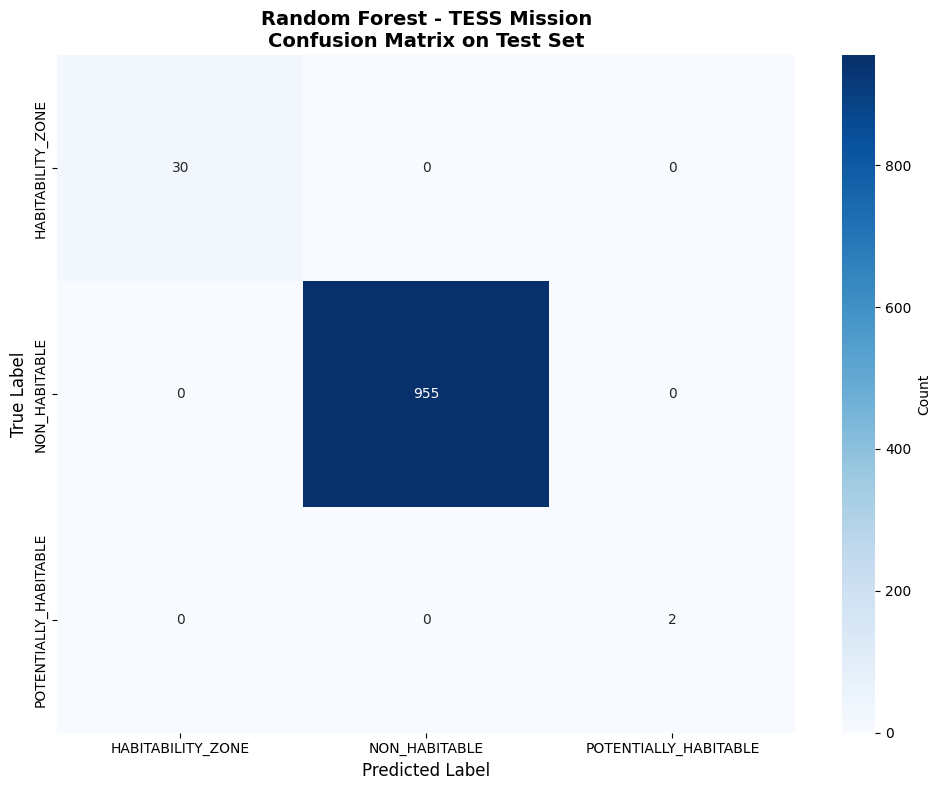

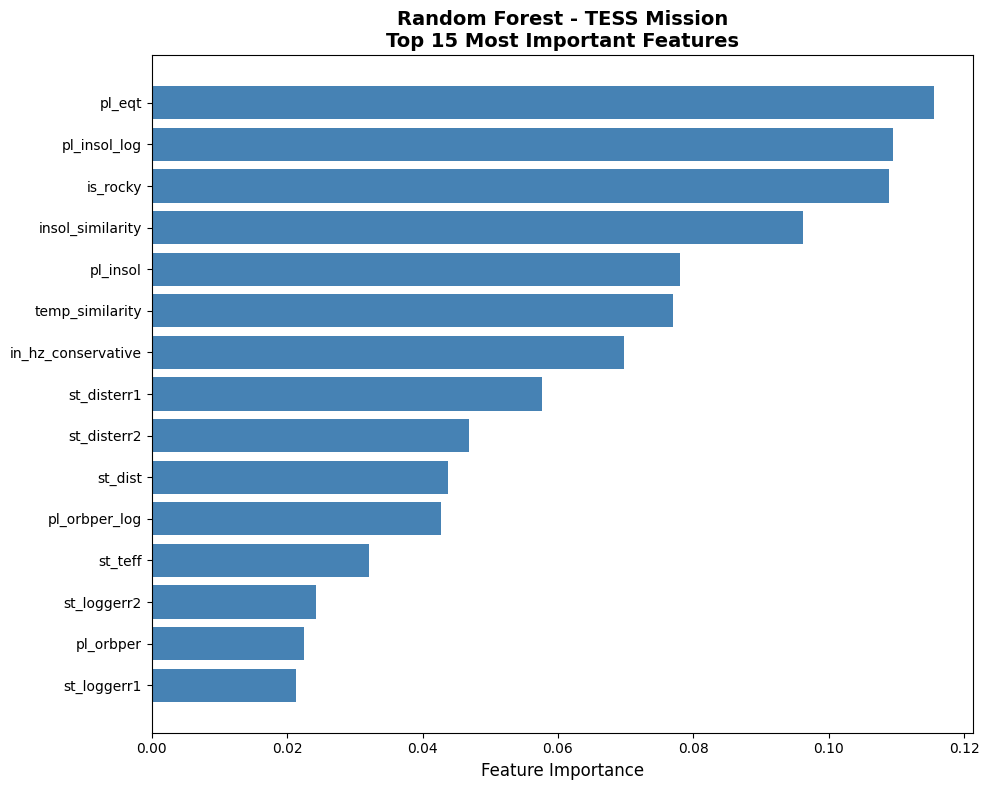

In [7]:
print("="*70)
print("Random Forest - Test Set Evaluation")
print("="*70)

# Predictions
y_pred = tess_rf_model.predict(X_test)
y_pred_proba = tess_rf_model.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
weighted_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
weighted_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\n✓ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\n📈 Weighted Metrics:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F1-Score:  {weighted_f1:.4f}")

# Per-class metrics
print(f"\n📊 Per-Class Performance:\n")
print(classification_report(y_test, y_pred, target_names=sorted(y_test_name.unique()), zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔢 Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test_name.unique()),
            yticklabels=sorted(y_test_name.unique()),
            cbar_kws={'label': 'Count'})
plt.title('Random Forest - TESS Mission\nConfusion Matrix on Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Feature importance
importances = tess_rf_model.feature_importances_
top_n = 15
indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importances[indices], color='steelblue')
plt.yticks(range(top_n), [feature_cols[i] for i in indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Random Forest - TESS Mission\nTop 15 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Store results
rf_results = {
    'model': 'Random Forest',
    'accuracy': accuracy,
    'weighted_f1': weighted_f1,
    'weighted_precision': weighted_precision,
    'weighted_recall': weighted_recall,
    'confusion_matrix': cm
}

---
## 7️⃣ Evaluate XGBoost on Test Set

XGBoost - Test Set Evaluation

✓ Overall Accuracy: 1.0000 (100.00%)

📈 Weighted Metrics:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

📊 Per-Class Performance:

                       precision    recall  f1-score   support

    HABITABILITY_ZONE       1.00      1.00      1.00        30
        NON_HABITABLE       1.00      1.00      1.00       955
POTENTIALLY_HABITABLE       1.00      1.00      1.00         2

             accuracy                           1.00       987
            macro avg       1.00      1.00      1.00       987
         weighted avg       1.00      1.00      1.00       987


🔢 Confusion Matrix:
[[ 30   0   0]
 [  0 955   0]
 [  0   0   2]]


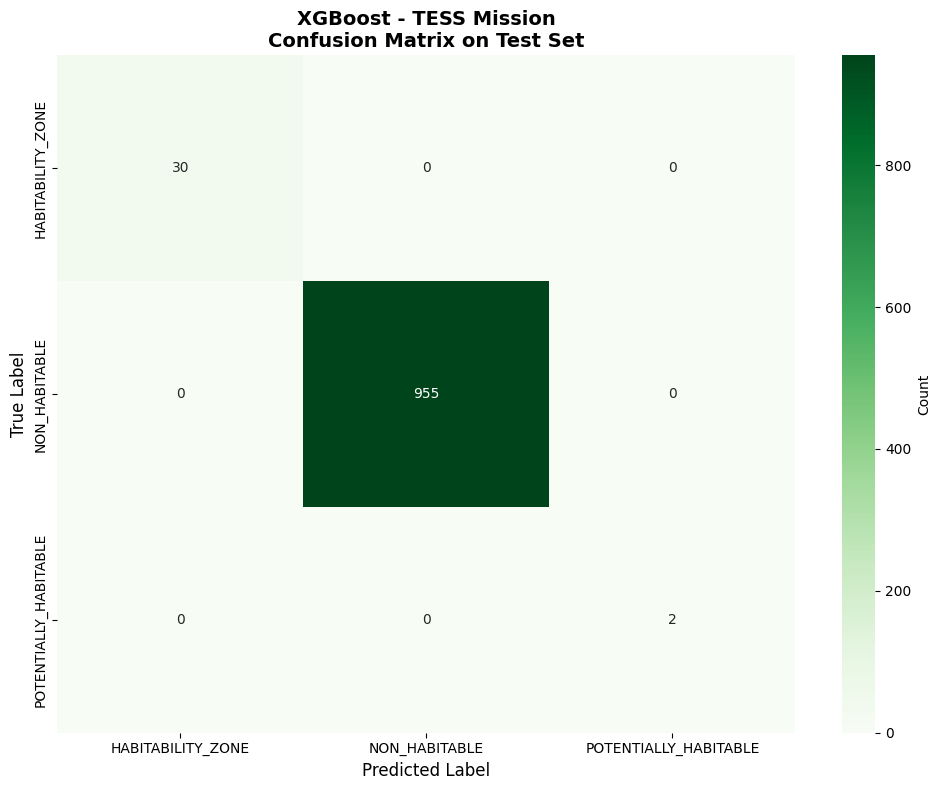

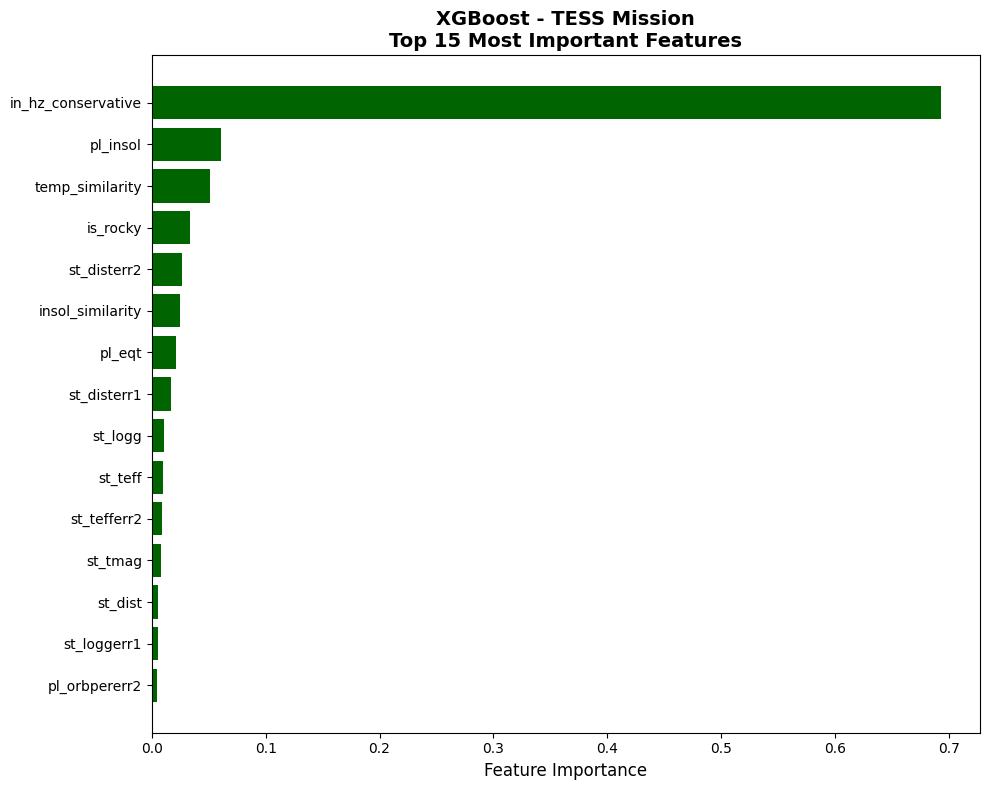

In [8]:
if tess_xgb_model is None:
    print("⚠ XGBoost model not available. Skipping evaluation.")
    xgb_results = None
else:
    print("="*70)
    print("XGBoost - Test Set Evaluation")
    print("="*70)
    
    # Predictions
    y_pred = tess_xgb_model.predict(X_test)
    y_pred_proba = tess_xgb_model.predict_proba(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    weighted_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n✓ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\n📈 Weighted Metrics:")
    print(f"  Precision: {weighted_precision:.4f}")
    print(f"  Recall:    {weighted_recall:.4f}")
    print(f"  F1-Score:  {weighted_f1:.4f}")
    
    # Per-class metrics
    print(f"\n📊 Per-Class Performance:\n")
    print(classification_report(y_test, y_pred, target_names=sorted(y_test_name.unique()), zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n🔢 Confusion Matrix:")
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=sorted(y_test_name.unique()),
                yticklabels=sorted(y_test_name.unique()),
                cbar_kws={'label': 'Count'})
    plt.title('XGBoost - TESS Mission\nConfusion Matrix on Test Set', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Feature importance
    importances = tess_xgb_model.feature_importances_
    top_n = 15
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(top_n), importances[indices], color='darkgreen')
    plt.yticks(range(top_n), [feature_cols[i] for i in indices])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title('XGBoost - TESS Mission\nTop 15 Most Important Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Store results
    xgb_results = {
        'model': 'XGBoost',
        'accuracy': accuracy,
        'weighted_f1': weighted_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'confusion_matrix': cm
    }

---
## 8️⃣ Summary & Model Comparison


TESS MISSION - MODEL PERFORMANCE SUMMARY

 Mission         Model  Accuracy  Weighted F1  Precision  Recall
   TESS Random Forest       1.0          1.0        1.0     1.0
   TESS       XGBoost       1.0          1.0        1.0     1.0

💾 Summary saved: f:\FYP\models\tess_model_performance.csv


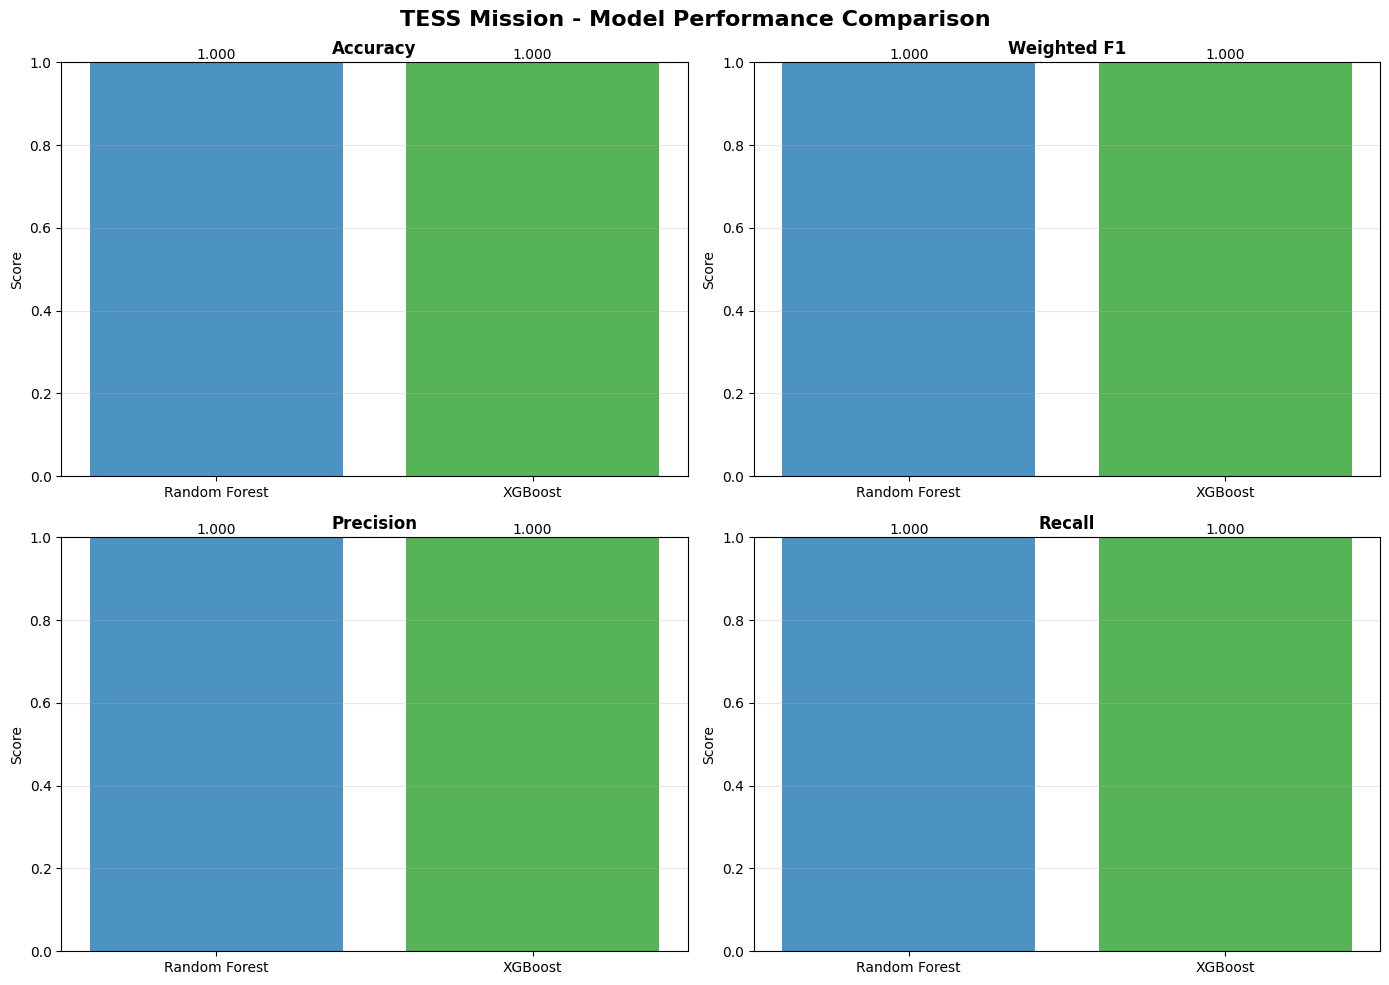


✓ TESS Mission Training Complete!


In [9]:
print("\n" + "="*70)
print("TESS MISSION - MODEL PERFORMANCE SUMMARY")
print("="*70)

# Create summary
summary_data = [
    {
        'Mission': 'TESS',
        'Model': 'Random Forest',
        'Accuracy': rf_results['accuracy'],
        'Weighted F1': rf_results['weighted_f1'],
        'Precision': rf_results['weighted_precision'],
        'Recall': rf_results['weighted_recall']
    }
]

if xgb_results is not None:
    summary_data.append({
        'Mission': 'TESS',
        'Model': 'XGBoost',
        'Accuracy': xgb_results['accuracy'],
        'Weighted F1': xgb_results['weighted_f1'],
        'Precision': xgb_results['weighted_precision'],
        'Recall': xgb_results['weighted_recall']
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# Save summary
summary_path = MODELS_DIR / 'tess_model_performance.csv'
summary_df.to_csv(summary_path, index=False)
print(f"\n💾 Summary saved: {summary_path}")

# Visualization
if len(summary_data) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('TESS Mission - Model Performance Comparison', fontsize=16, fontweight='bold')
    
    metrics = ['Accuracy', 'Weighted F1', 'Precision', 'Recall']
    colors = ['#1f77b4', '#2ca02c']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        values = summary_df[metric].values
        models = summary_df['Model'].values
        
        bars = ax.bar(models, values, color=colors[:len(models)], alpha=0.8)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_ylabel('Score')
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("✓ TESS Mission Training Complete!")
print("="*70)

---
## ✅ TESS Mission Complete!

### Models Trained:
- ✓ Random Forest Classifier
- ✓ XGBoost Classifier (if available)

### Models Saved:
```
models/
├── tess_random_forest_model.pkl
├── tess_xgboost_model.pkl
└── tess_model_performance.csv
```

### Next Steps:
- All three missions complete (K2, Kepler, TESS)
- Proceed to Step 2.2: Model Comparison & Ensemble